# 04 - Tournament Simulation

Monte Carlo simulate the full 48-team 2026 World Cup and visualize title and advancement probabilities.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.models import PoissonModel
from wcpredictor.simulation import TournamentSimulator
import numpy as np

In [2]:
tr = build_training_matches(load_matches(config), config)
poisson = PoissonModel(config).fit(tr)
groups = load_groups(config)
sim = TournamentSimulator(poisson, groups, config)
report = sim.run(n_simulations=3000)
report.table.head(15)

,team,group,p_advance,p_round_of_16,p_quarterfinal,p_semifinal,p_final,p_winner
0,France,I,0.947667,0.723333,0.524000,0.365667,0.257667,0.171333
1,Croatia,L,0.902667,0.640667,0.428333,0.272000,0.165667,0.096333
2,Brazil,H,0.943333,0.653667,0.408667,0.258000,0.164667,0.086000
3,Spain,C,0.883000,0.615000,0.391000,0.245667,0.141333,0.078000
4,Netherlands,J,0.844000,0.557667,0.342000,0.199333,0.101333,0.057667
5,Argentina,L,0.860667,0.539333,0.328333,0.180667,0.099667,0.054667
6,Morocco,F,0.928667,0.586667,0.341333,0.195667,0.100667,0.048667
7,Germany,A,0.847333,0.516000,0.287000,0.155000,0.087333,0.045000
8,Uruguay,B,0.926333,0.557667,0.327667,0.176667,0.088000,0.043000
9,Belgium,K,0.899333,0.518667,0.279667,0.136000,0.063333,0.030333


## Title probabilities (top 15)

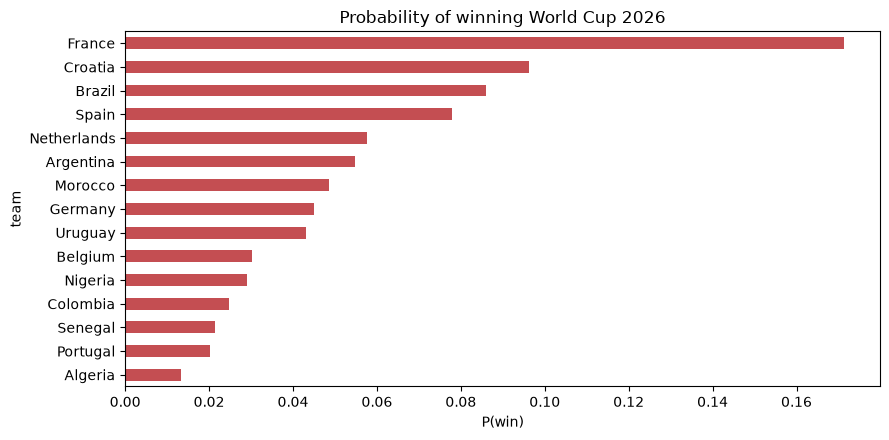

In [3]:
top = report.table.head(15).iloc[::-1]
ax = top.plot.barh(x='team', y='p_winner', legend=False, color='#C44E52')
ax.set_title('Probability of winning World Cup 2026')
ax.set_xlabel('P(win)'); plt.tight_layout(); plt.show()

## Stage-by-stage funnel for the favourites

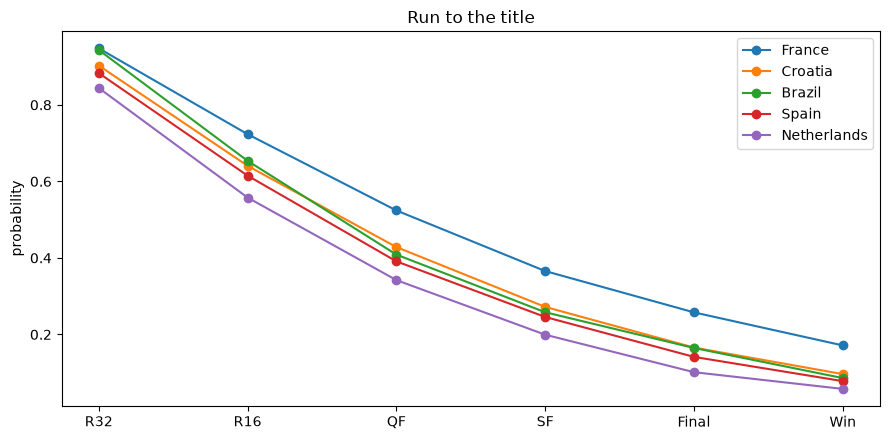

In [4]:
stages = ['p_advance', 'p_round_of_16', 'p_quarterfinal',
          'p_semifinal', 'p_final', 'p_winner']
labels = ['R32', 'R16', 'QF', 'SF', 'Final', 'Win']
fig, ax = plt.subplots()
for _, row in report.table.head(5).iterrows():
    ax.plot(labels, [row[s] for s in stages], marker='o', label=row['team'])
ax.set_ylabel('probability'); ax.set_title('Run to the title')
ax.legend(); plt.tight_layout(); plt.show()

## One simulated tournament (example bracket)

In [5]:
rng = np.random.default_rng(7)
result = sim.simulate_once(rng)
print('Champion:', result['champion'])
print('Finalists:', sorted(result['reached']['final']))
print('Semifinalists:', sorted(result['reached']['semifinal']))

Champion: France
Finalists: ['France', 'Senegal']
Semifinalists: ['Austria', 'France', 'Portugal', 'Senegal']


## Probability of topping the group

In [6]:
# Re-run focusing on group winners would require per-group stats;
# here we show advancement probability grouped by draw group.
report.table.groupby('group')['p_advance'].mean().sort_values(ascending=False)

group
D    0.678500
G    0.674167
J    0.673500
C    0.672000
A    0.671167
L    0.669583
B    0.664333
F    0.664333
E    0.663583
K    0.663500
I    0.656917
H    0.648417
Name: p_advance, dtype: float64